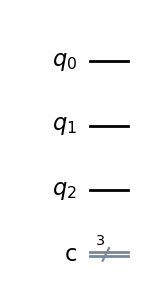

In [11]:
from qiskit import  QuantumCircuit,transpile

circuit = QuantumCircuit(3,3)
circuit.draw('mpl')

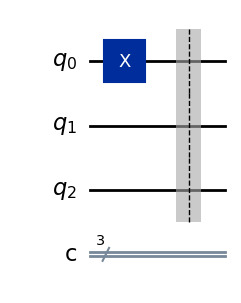

In [12]:
circuit.x(0)
circuit.barrier()
circuit.draw('mpl')

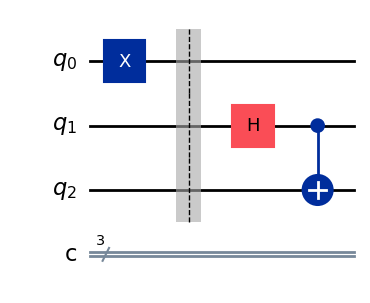

In [13]:
circuit.h(1)
circuit.cx(1,2)
circuit.draw('mpl')

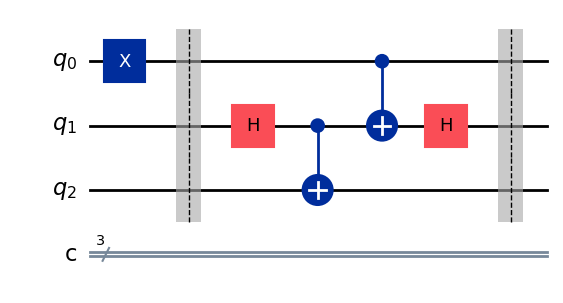

In [14]:
circuit.cx(0,1)
circuit.h(1)
circuit.barrier()
circuit.draw('mpl')

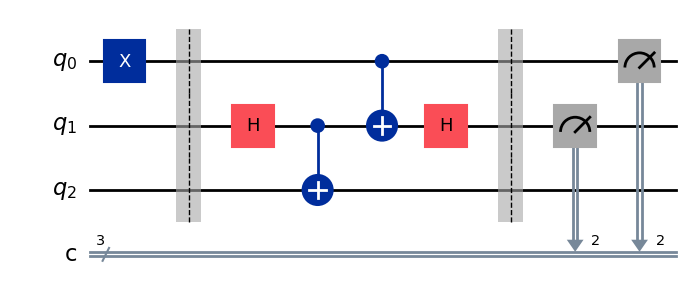

In [15]:
circuit.measure(1,2)
circuit.measure(0,2)
circuit.draw('mpl')

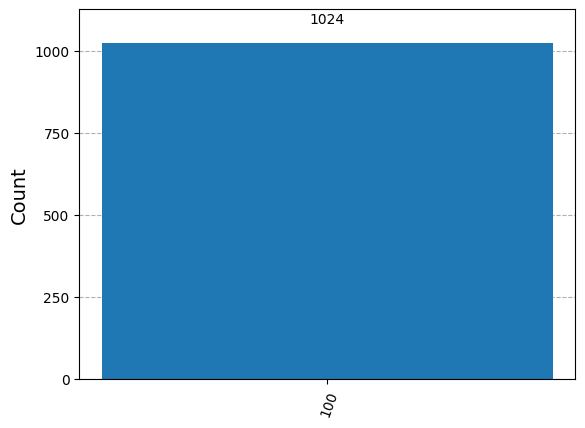

In [18]:
from qiskit.visualization import plot_histogram
from qiskit_aer import  Aer
sim = AerSimulator()
#circuit.measure(2,2)
#result = sim.run(circuit, backend=sim , shots=100).result()
#counts = result.get_counts()
run = transpile(circuit,sim)
result = sim.run(run).result()
counts = result.get_counts() 
plot_histogram(counts)

In [5]:
from qiskit import QuantumCircuit, transpile, assemble
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator


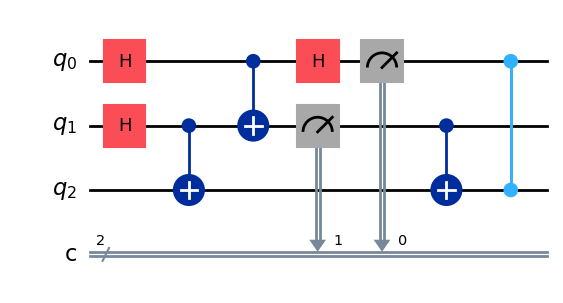

In [6]:
# Create a quantum circuit with 3 qubits and 3 classical bits
qc = QuantumCircuit(3, 2)

# Step 1: Prepare the quantum state to teleport (Example: |+> = (|0> + |1>) / sqrt(2))
qc.h(0)  # Apply Hadamard to qubit 0 (Alice's qubit)

# Step 2: Create entanglement between qubit 1 and 2
qc.h(1)  # Apply Hadamard gate to qubit 1
qc.cx(1, 2)  # Apply CNOT with qubit 1 as control and qubit 2 as target

# Step 3: Bell measurement of Alice's qubits (0 and 1)
qc.cx(0, 1)  # Apply CNOT gate with qubit 0 as control and qubit 1 as target
qc.h(0)  # Apply Hadamard to qubit 0

# Step 4: Measure qubits 0 and 1 and send classical bits to Bob
qc.measure(0, 0)
qc.measure(1, 1)

# Step 5: Bob applies corrections based on classical bits received
qc.cx(1, 2)  # Apply CNOT if qubit 1 is |1>
qc.cz(0, 2)  # Apply Z gate if qubit 0 is |1>

# Draw the circuit
qc.draw("mpl")


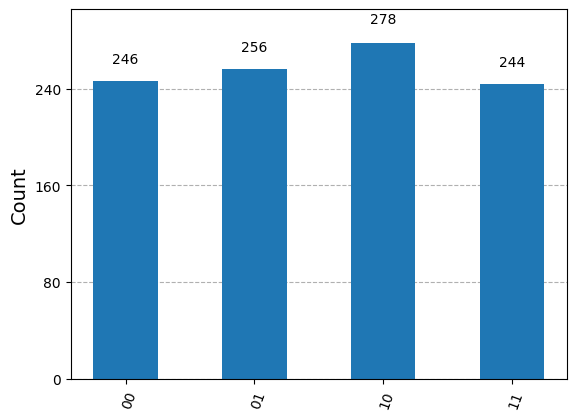

In [9]:


# Use AerSimulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
compiled_circuit = transpile(qc, simulator)

# Run the circuit directly (no assemble())
result = simulator.run(compiled_circuit).result()

# Get and plot results
counts = result.get_counts()
plot_histogram(counts)

